# Arsalan Ibrahim | CRH-2026-AI-034 | Code Room Hub | Week 1

# Week 1 - Transformer Decoder Block from Scratch (PyTorch)

Building a decoder-only transformer 

Order I am following:

1. Self attention (single head)
2. Positional encoding (sinusoidal, then rotary)
3. Multi head attention
4. RMSNorm
5. SwiGLU feed forward
6. Putting it together into a decoder block
7. Stacking blocks into a tiny language model
8. KV cache, and a check that it changes speed but not output


In [1]:
import math
import time

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(0)
print("torch", torch.__version__)
print("device available:", "cuda" if torch.cuda.is_available() else "cpu")

torch 2.11.0+cu128
device available: cuda


## 1. Self attention

For one head, with queries `Q`, keys `K` and values `V`:

$$\text{Attention}(Q,K,V) = \text{softmax}\left(\frac{QK^{T}}{\sqrt{d_k}}\right)V$$

`Q @ K.T` gives a score for every (query, key) pair, so the result is `T x T`.
The division by `sqrt(d_k)` keeps the scores from growing with dimension, which would push
softmax into a region where the gradients are almost zero.

Because this is a decoder, position `i` must not see position `j > i`. I enforce that by
setting those scores to `-inf` before the softmax, so they come out as exactly 0 probability.

In [2]:
def single_head_attention(q, k, v, causal=True):
    """q, k, v: (B, T, d_k). Returns the attended values and the attention weights."""
    d_k = q.shape[-1]
    scores = (q @ k.transpose(-2, -1)) / math.sqrt(d_k)

    if causal:
        T = scores.shape[-1]
        mask = torch.triu(torch.ones(T, T, dtype=torch.bool), diagonal=1)
        scores = scores.masked_fill(mask, float("-inf"))

    weights = torch.softmax(scores, dim=-1)
    return weights @ v, weights


# quick look at the mask working
q = k = v = torch.randn(1, 5, 8)
out, w = single_head_attention(q, k, v)

print("output:", out.shape)
print("attention weights (rows should be lower triangular and sum to 1):")
print(w[0].round(decimals=2))
print("row sums:", w[0].sum(-1))

output: torch.Size([1, 5, 8])
attention weights (rows should be lower triangular and sum to 1):
tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2700, 0.7300, 0.0000, 0.0000, 0.0000],
        [0.0100, 0.0100, 0.9800, 0.0000, 0.0000],
        [0.0800, 0.1800, 0.4300, 0.3000, 0.0000],
        [0.0100, 0.0200, 0.0700, 0.0300, 0.8800]])
row sums: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000])


## 2. Positional encoding

Attention on its own has no idea about order. Shuffle the tokens and every token still sees
the same set of other tokens. So position has to be injected somewhere.

### 2a. Sinusoidal (original transformer)

A fixed, non-learned matrix added to the embeddings. Even dimensions use sine, odd use cosine,
with the wavelength growing geometrically across dimensions.

positional encoding: torch.Size([64, 128])


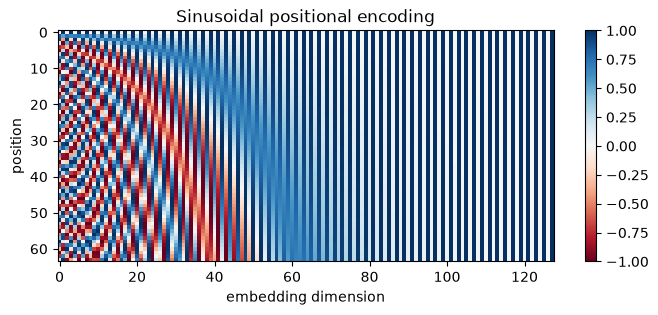

In [3]:
def sinusoidal_positions(seq_len, d_model):
    pos = torch.arange(seq_len).unsqueeze(1).float()
    i = torch.arange(0, d_model, 2).float()
    denom = torch.pow(10000.0, i / d_model)

    pe = torch.zeros(seq_len, d_model)
    pe[:, 0::2] = torch.sin(pos / denom)
    pe[:, 1::2] = torch.cos(pos / denom)
    return pe


pe = sinusoidal_positions(64, 128)
print("positional encoding:", pe.shape)

plt.figure(figsize=(8, 3))
plt.imshow(pe.numpy(), aspect="auto", cmap="RdBu")
plt.xlabel("embedding dimension")
plt.ylabel("position")
plt.title("Sinusoidal positional encoding")
plt.colorbar()
plt.show()

### 2b. Rotary positional embedding (RoPE)

None of the models I compare later use the sinusoidal version. Llama, Mistral, Qwen, Gemma,
DeepSeek and Phi all use RoPE, so this is the one I actually put in my block.

The difference: sinusoidal is *added* to the embeddings once at the input. RoPE *rotates* the
query and key vectors inside every attention layer, by an angle proportional to the position.
Because a dot product between two rotated vectors only depends on the difference of their
angles, the attention score ends up depending on relative distance rather than absolute
position. That is what lets people stretch the context window later by changing `theta`.

I keep an `offset` argument because when I generate with a KV cache, the new token is not at
position 0 even though it is the only token in the tensor.

In [4]:
class RotaryEmbedding(nn.Module):
    def __init__(self, head_dim, theta=10000.0, max_len=4096):
        super().__init__()
        inv_freq = 1.0 / (theta ** (torch.arange(0, head_dim, 2).float() / head_dim))
        t = torch.arange(max_len).float()
        freqs = torch.outer(t, inv_freq)            # (max_len, head_dim/2)
        emb = torch.cat([freqs, freqs], dim=-1)     # (max_len, head_dim)
        self.register_buffer("cos", emb.cos(), persistent=False)
        self.register_buffer("sin", emb.sin(), persistent=False)

    def forward(self, seq_len, offset=0):
        return self.cos[offset:offset + seq_len], self.sin[offset:offset + seq_len]


def rotate_half(x):
    half = x.shape[-1] // 2
    x1, x2 = x[..., :half], x[..., half:]
    return torch.cat([-x2, x1], dim=-1)


def apply_rope(x, cos, sin):
    """x: (B, heads, T, head_dim). cos/sin: (T, head_dim)."""
    cos = cos[None, None, :, :]
    sin = sin[None, None, :, :]
    return x * cos + rotate_half(x) * sin


# sanity check: rotating both vectors by the same position must not change their dot product,
# and the dot product of two vectors should only depend on how far apart they are
rope = RotaryEmbedding(head_dim=32)
a = torch.randn(1, 1, 1, 32)
b = torch.randn(1, 1, 1, 32)

def dot_at(p1, p2):
    c1, s1 = rope(1, offset=p1)
    c2, s2 = rope(1, offset=p2)
    return (apply_rope(a, c1, s1) * apply_rope(b, c2, s2)).sum().item()

print("positions (0, 3): %.4f" % dot_at(0, 3))
print("positions (10, 13): %.4f" % dot_at(10, 13))
print("same gap gives the same score, so RoPE is relative")

positions (0, 3): 8.3459
positions (10, 13): 8.3459
same gap gives the same score, so RoPE is relative


## 3. Multi head attention

One head can only average one way. Splitting `d_model` into `n_heads` slices of size
`d_model // n_heads` lets different heads specialise, and it costs the same FLOPs because the
head dimension shrinks as the head count grows.

Shapes go `(B, T, d_model)` -> `(B, n_heads, T, head_dim)` -> back again.

Three things folded in here that I need later:

- **RoPE** applied to `q` and `k` (not `v`)
- **KV cache**: optionally take previous keys/values, concatenate, and return the new ones
- **Grouped query attention (GQA)**: `n_kv_heads` can be smaller than `n_heads`, so several
  query heads share one key/value head. `k_proj` and `v_proj` get narrower, and each kv head is
  repeated before the matmul. All six models I benchmark use this, and it is the single change
  that most reduces cache memory. Setting `n_kv_heads = n_heads` gives plain MHA back.

The mask has to be built with absolute positions rather than a plain triangular matrix,
because with a cache the query tensor may be a single token sitting at position 50 while the
key tensor is 51 tokens long.

In [5]:
def repeat_kv(x, n_rep):
    """(B, n_kv_heads, T, head_dim) -> (B, n_kv_heads * n_rep, T, head_dim)"""
    if n_rep == 1:
        return x
    B, n_kv, T, hd = x.shape
    return x[:, :, None].expand(B, n_kv, n_rep, T, hd).reshape(B, n_kv * n_rep, T, hd)


class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model, n_heads, n_kv_heads=None, dropout=0.0):
        super().__init__()
        assert d_model % n_heads == 0, "d_model must divide evenly by n_heads"
        self.n_heads = n_heads
        self.n_kv_heads = n_kv_heads or n_heads
        assert n_heads % self.n_kv_heads == 0, "n_heads must be a multiple of n_kv_heads"
        self.n_rep = n_heads // self.n_kv_heads
        self.head_dim = d_model // n_heads

        # no bias, same as llama / mistral
        # k and v are narrower than q when n_kv_heads < n_heads
        self.q_proj = nn.Linear(d_model, d_model, bias=False)
        self.k_proj = nn.Linear(d_model, self.n_kv_heads * self.head_dim, bias=False)
        self.v_proj = nn.Linear(d_model, self.n_kv_heads * self.head_dim, bias=False)
        self.o_proj = nn.Linear(d_model, d_model, bias=False)
        self.dropout = nn.Dropout(dropout)

    def split_heads(self, x, n_heads):
        B, T, _ = x.shape
        return x.view(B, T, n_heads, self.head_dim).transpose(1, 2)

    def forward(self, x, rope=None, kv_cache=None, return_weights=False):
        B, T, _ = x.shape
        past_len = 0 if kv_cache is None else kv_cache[0].shape[2]

        q = self.split_heads(self.q_proj(x), self.n_heads)
        k = self.split_heads(self.k_proj(x), self.n_kv_heads)
        v = self.split_heads(self.v_proj(x), self.n_kv_heads)

        if rope is not None:
            cos, sin = rope(T, offset=past_len)
            q = apply_rope(q, cos, sin)
            k = apply_rope(k, cos, sin)

        if kv_cache is not None:
            past_k, past_v = kv_cache
            k = torch.cat([past_k, k], dim=2)
            v = torch.cat([past_v, v], dim=2)
        new_cache = (k, v)          # cached narrow, before repeating

        # repeat each kv head so every query head has one to attend to
        k_full = repeat_kv(k, self.n_rep)
        v_full = repeat_kv(v, self.n_rep)

        total_len = k_full.shape[2]
        scores = (q @ k_full.transpose(-2, -1)) / math.sqrt(self.head_dim)

        # query at absolute position past_len + i may only attend to keys 0 .. past_len + i
        q_pos = torch.arange(past_len, past_len + T, device=x.device).unsqueeze(1)
        k_pos = torch.arange(total_len, device=x.device).unsqueeze(0)
        scores = scores.masked_fill(k_pos > q_pos, float("-inf"))

        weights = self.dropout(torch.softmax(scores, dim=-1))
        out = weights @ v_full
        out = out.transpose(1, 2).contiguous().view(B, T, -1)
        out = self.o_proj(out)

        if return_weights:
            return out, new_cache, weights
        return out, new_cache


x = torch.randn(2, 10, 64)

mha = MultiHeadSelfAttention(d_model=64, n_heads=8)              # plain MHA
out, cache, w = mha(x, return_weights=True)
print("MHA  out:", tuple(out.shape), "cached k:", tuple(cache[0].shape))

gqa = MultiHeadSelfAttention(d_model=64, n_heads=8, n_kv_heads=2)  # grouped query
out_g, cache_g, _ = gqa(x, return_weights=True)
print("GQA  out:", tuple(out_g.shape), "cached k:", tuple(cache_g[0].shape))
print("")
print("same output shape, cache is %dx smaller" % (cache[0].numel() // cache_g[0].numel()))

MHA  out: (2, 10, 64) cached k: (2, 8, 10, 8)
GQA  out: (2, 10, 64) cached k: (2, 2, 10, 8)

same output shape, cache is 4x smaller


## 4. RMSNorm

LayerNorm subtracts the mean and divides by the standard deviation. RMSNorm skips the mean
subtraction and only divides by the root mean square


In [6]:
class RMSNorm(nn.Module):
    def __init__(self, dim, eps=1e-6):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(dim))

    def forward(self, x):
        rms = x.pow(2).mean(dim=-1, keepdim=True).add(self.eps).rsqrt()
        return x * rms * self.weight


norm = RMSNorm(64)
y = norm(torch.randn(2, 10, 64) * 5)
print("rms per token after norm (should be about 1):", y.pow(2).mean(-1).sqrt().flatten()[:5])

rms per token after norm (should be about 1): tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000], grad_fn=<SliceBackward0>)


## 5. Feed forward (SwiGLU)

The original block used `Linear -> ReLU -> Linear` with a 4x hidden size. Modern models use a
gated variant, SwiGLU:

`down( silu(gate(x)) * up(x) )`

That is three matrices instead of two, so the hidden size is usually set to about `8/3 * d_model`
to keep the parameter count roughly the same as the old 4x version.

In [7]:
class SwiGLU(nn.Module):
    def __init__(self, d_model, hidden=None):
        super().__init__()
        hidden = hidden or int(d_model * 8 / 3)
        self.gate = nn.Linear(d_model, hidden, bias=False)
        self.up = nn.Linear(d_model, hidden, bias=False)
        self.down = nn.Linear(hidden, d_model, bias=False)

    def forward(self, x):
        return self.down(F.silu(self.gate(x)) * self.up(x))


ffn = SwiGLU(64)
print("hidden size:", ffn.gate.out_features)
print("out:", tuple(ffn(torch.randn(2, 10, 64)).shape))
print("params:", sum(p.numel() for p in ffn.parameters()))

hidden size: 170
out: (2, 10, 64)
params: 32640


## 6. The decoder block

Two residual sublayers:

```
x = x + attention(norm(x))
x = x + ffn(norm(x))
```

The residual connections are what let gradients reach the early layers in a deep stack. The
cache is passed straight through so the block can be used in generation.

In [8]:
class DecoderBlock(nn.Module):
    def __init__(self, d_model, n_heads, n_kv_heads=None, dropout=0.0):
        super().__init__()
        self.norm1 = RMSNorm(d_model)
        self.attn = MultiHeadSelfAttention(d_model, n_heads, n_kv_heads, dropout)
        self.norm2 = RMSNorm(d_model)
        self.ffn = SwiGLU(d_model)

    def forward(self, x, rope=None, kv_cache=None):
        h, new_cache = self.attn(self.norm1(x), rope=rope, kv_cache=kv_cache)
        x = x + h
        x = x + self.ffn(self.norm2(x))
        return x, new_cache


block = DecoderBlock(64, 8)
out, _ = block(torch.randn(2, 10, 64))
print("block out:", tuple(out.shape))
print("block params:", sum(p.numel() for p in block.parameters()))

block out: (2, 10, 64)
block params: 49152


## 7. Stacking into a tiny language model

Embedding -> N blocks -> final norm -> projection back to vocab size.

I tie the output projection to the embedding matrix, which is what most small models do. It
saves `vocab_size * d_model` parameters, and at this scale the embedding is a big share of the
total.

In [9]:
class TinyDecoderLM(nn.Module):
    def __init__(self, vocab_size, d_model=256, n_heads=8, n_kv_heads=2,
                 n_layers=4, max_len=512):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, d_model)
        self.rope = RotaryEmbedding(d_model // n_heads, max_len=max_len)
        self.blocks = nn.ModuleList(
            [DecoderBlock(d_model, n_heads, n_kv_heads) for _ in range(n_layers)]
        )
        self.norm = RMSNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size, bias=False)
        self.head.weight = self.embed.weight   # weight tying

    def forward(self, idx, kv_caches=None):
        x = self.embed(idx)
        new_caches = []
        for i, block in enumerate(self.blocks):
            cache = None if kv_caches is None else kv_caches[i]
            x, cached = block(x, rope=self.rope, kv_cache=cache)
            new_caches.append(cached)
        return self.head(self.norm(x)), new_caches


VOCAB = 1000
model = TinyDecoderLM(VOCAB).eval()

total = sum(p.numel() for p in model.parameters())
print("total params: {:,}".format(total))

tokens = torch.randint(0, VOCAB, (2, 16))
logits, caches = model(tokens)
print("logits:", tuple(logits.shape))
print("cached keys per layer:", tuple(caches[0][0].shape))

total params: 3,008,768
logits: (2, 16, 1000)
cached keys per layer: (2, 2, 16, 32)


### Causality check

If the block is really causal, changing the last token of a sequence must leave the logits at
every earlier position untouched. If this fails, the mask is wrong.

In [10]:
a = torch.randint(0, VOCAB, (1, 12))
b = a.clone()
b[0, -1] = (b[0, -1] + 1) % VOCAB

with torch.no_grad():
    logits_a, _ = model(a)
    logits_b, _ = model(b)

print("earlier logits unchanged:", torch.allclose(logits_a[0, :-1], logits_b[0, :-1], atol=1e-5))
print("last position changed:", not torch.allclose(logits_a[0, -1], logits_b[0, -1], atol=1e-5))

earlier logits unchanged: True
last position changed: True


## 8. KV cache

Without a cache, generating token `n` means re-running attention over all `n` tokens, and the
keys and values for tokens `0..n-1` are recomputed identically every single step. Total work
grows quadratically with the number of tokens generated.

With a cache, I keep `k` and `v` from previous steps and only compute them for the one new
token. Work per step becomes roughly constant, at the cost of memory:

`2 (k and v) * n_layers * n_heads * head_dim * seq_len * batch * bytes_per_element`

That memory term is why long context is expensive at inference time, and it is the number I
will be watching when I profile the real models later this week.

First correctness, then speed. Feeding the sequence one token at a time with the cache must
give the same logits as one full forward pass.

In [11]:
seq = torch.randint(0, VOCAB, (1, 20))

with torch.no_grad():
    full_logits, _ = model(seq)

    caches = None
    step_logits = []
    for t in range(seq.shape[1]):
        out, caches = model(seq[:, t:t + 1], kv_caches=caches)
        step_logits.append(out)
    incremental = torch.cat(step_logits, dim=1)

print("cached matches full pass:", torch.allclose(full_logits, incremental, atol=1e-4))
print("max difference: {:.2e}".format((full_logits - incremental).abs().max().item()))

cached matches full pass: True
max difference: 1.37e-04


In [12]:
def generate(model, prompt, n_new, use_cache):
    """Greedy decode. Returns the full sequence."""
    seq = prompt.clone()
    with torch.no_grad():
        if not use_cache:
            for _ in range(n_new):
                logits, _ = model(seq)
                nxt = logits[:, -1:].argmax(-1)
                seq = torch.cat([seq, nxt], dim=1)
        else:
            logits, caches = model(prompt)
            nxt = logits[:, -1:].argmax(-1)
            seq = torch.cat([seq, nxt], dim=1)
            for _ in range(n_new - 1):
                logits, caches = model(nxt, kv_caches=caches)
                nxt = logits[:, -1:].argmax(-1)
                seq = torch.cat([seq, nxt], dim=1)
    return seq


prompt = torch.randint(0, VOCAB, (1, 8))
results = {}

for n_new in [32, 64, 128]:
    t0 = time.perf_counter()
    slow = generate(model, prompt, n_new, use_cache=False)
    t_slow = time.perf_counter() - t0

    t0 = time.perf_counter()
    fast = generate(model, prompt, n_new, use_cache=True)
    t_fast = time.perf_counter() - t0

    results[n_new] = (t_slow, t_fast)
    same = torch.equal(slow, fast)
    print("%4d tokens | no cache %6.3fs | cache %6.3fs | %.2fx faster | identical output: %s"
          % (n_new, t_slow, t_fast, t_slow / t_fast, same))

  32 tokens | no cache  0.103s | cache  0.062s | 1.66x faster | identical output: True
  64 tokens | no cache  0.243s | cache  0.145s | 1.68x faster | identical output: True
 128 tokens | no cache  0.657s | cache  0.297s | 2.21x faster | identical output: True


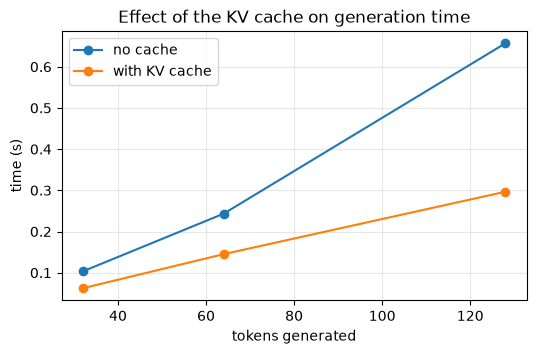

In [13]:
lengths = list(results.keys())
plt.figure(figsize=(6, 3.5))
plt.plot(lengths, [results[n][0] for n in lengths], marker="o", label="no cache")
plt.plot(lengths, [results[n][1] for n in lengths], marker="o", label="with KV cache")
plt.xlabel("tokens generated")
plt.ylabel("time (s)")
plt.title("Effect of the KV cache on generation time")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### What GQA actually saves

The cache is stored at `n_kv_heads` width, before the repeat. So the saving is exactly the
ratio `n_heads / n_kv_heads`, and it applies to every layer and every token.

This is why the ratio is a headline number in model configs. It does not change output shape or
parameter count much, but it decides how long a context the model can hold on a given card.

In [14]:
def cache_bytes(n_layers, n_kv_heads, head_dim, seq_len, bytes_per_el=2):
    return 2 * n_layers * n_kv_heads * head_dim * seq_len * bytes_per_el


# same model shape, different kv head counts
LAYERS, HEADS, HEAD_DIM = 32, 32, 128

print("%-12s %14s %14s" % ("n_kv_heads", "cache @ 4k", "cache @ 32k"))
for n_kv in [32, 8, 4, 1]:
    at_4k = cache_bytes(LAYERS, n_kv, HEAD_DIM, 4096) / 1e9
    at_32k = cache_bytes(LAYERS, n_kv, HEAD_DIM, 32768) / 1e9
    label = "%d%s" % (n_kv, " (plain MHA)" if n_kv == HEADS else "")
    print("%-12s %11.2f GB %11.2f GB" % (label, at_4k, at_32k))

print("\ngoing from 32 kv heads to 8 cuts the cache to a quarter")

n_kv_heads       cache @ 4k    cache @ 32k
32 (plain MHA)        2.15 GB       17.18 GB
8                   0.54 GB        4.29 GB
4                   0.27 GB        2.15 GB
1                   0.07 GB        0.54 GB

going from 32 kv heads to 8 cuts the cache to a quarter
